In [1]:
# ! pip install -U bitsandbytes>=0.46.1 trl

In [2]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training ,LoraConfig, get_peft_model
from datetime import datetime
from datasets import load_dataset, DatasetDict
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from trl import SFTTrainer, SFTConfig
import wandb

In [3]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

api_key = userdata.get('WANDB_API_KEY')
wandb.login(key=api_key, relogin=True)
wandb.init(project="LLAMA_Tuning", name="LLAMA_3B-T4")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: essamhamza2004 (essamhamza2004-cairo-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
# Load Model In 4 Bit
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16,
    token=userdata.get('HF_Token'),
)
model = prepare_model_for_kbit_training(base_model)

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [5]:
print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:,.2f} GB")

Memory footprint: 2.99 GB


In [6]:
base_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNo

In [7]:
# Configure the LoRA hyperparameters
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [8]:
# Wrap the base model with your LoRA configuration
peft_model = get_peft_model(model, lora_config)

# Print out the savings!
peft_model.print_trainable_parameters()

trainable params: 9,175,040 || all params: 3,221,924,864 || trainable%: 0.2848


In [9]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL , token=userdata.get('HF_Token'))

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.chat_template = "{% set loop_messages = messages %}{% for message in loop_messages %}{% set content = '<|start_header_id|>' + message['role'] + '<|end_header_id|>\n\n'+ message['content'] | trim + '<|eot_id|>' %}{% if loop.index0 == 0 %}{% set content = bos_token + content %}{% endif %}{{ content }}{% endfor %}{% if add_generation_prompt %}{{ '<|start_header_id|>assistant<|end_header_id|>\n\n' }}{% endif %}"

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

In [10]:
# Download and Format Dataset
dataset = load_dataset("mlabonne/FineTome-100k", split="train")

def format_conversation(row):
    messages = []

    for m in row["conversations"]:
        if m["from"] == "human":
            role = "user"
        else:
            role = "assistant"
        message_dict = {
            "role": role,
            "content": m["value"]
        }
        messages.append(message_dict)

    row["text"] = tokenizer.apply_chat_template(messages, tokenize=False)
    return row

print("Grabbing a 2,000 example subset...")
small_dataset = dataset.select(range(2000))

print("Formatting dataset to ChatML...")
formatted_dataset = small_dataset.map(format_conversation)

README.md:   0%|          | 0.00/982 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Grabbing a 2,000 example subset...
Formatting dataset to ChatML...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [11]:
initial_split = formatted_dataset.train_test_split(test_size=0.1, seed=42)

test_val_split = initial_split['test'].train_test_split(test_size=0.5, seed=42)

final_dataset = DatasetDict({
    'train': initial_split['train'],
    'validation': test_val_split['train'],
    'test': test_val_split['test']
})

print(final_dataset)

DatasetDict({
    train: Dataset({
        features: ['conversations', 'source', 'score', 'text'],
        num_rows: 1800
    })
    validation: Dataset({
        features: ['conversations', 'source', 'score', 'text'],
        num_rows: 100
    })
    test: Dataset({
        features: ['conversations', 'source', 'score', 'text'],
        num_rows: 100
    })
})


In [12]:
# Grab a random index from training pool
sample_index = random.randint(0, len(final_dataset["train"]) - 1)
sample_data = final_dataset["train"][sample_index]

print(f"=========================================")
print(f" INSPECTING DATA ROW: {sample_index}")
print(f"=========================================\n")

print("1. THE RAW DATA (From the original Hugging Face dataset):")
for message in sample_data["conversations"]:
    speaker = message["from"].upper()
    print(f"[{speaker}]: {message['value'][:150]}...")

print("\n-----------------------------------------\n")

print("2. THE FORMATTED TEXT (Exactly what Llama 3 will read during training):")
print(sample_data["text"])

print(f"\n=========================================")

 INSPECTING DATA ROW: 61

1. THE RAW DATA (From the original Hugging Face dataset):
[HUMAN]: How have the unique reproductive strategies of marsupials, such as giving birth to underdeveloped offspring that complete their development in a pouch...
[GPT]: Marsupials, a group of mammals primarily found in Australia and nearby islands, have evolved unique reproductive strategies that have allowed them to ...

-----------------------------------------

2. THE FORMATTED TEXT (Exactly what Llama 3 will read during training):
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

How have the unique reproductive strategies of marsupials, such as giving birth to underdeveloped offspring that complete their development in a pouch, contributed to their evolution and adaptation to different habitats?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Marsupials, a group of mammals primarily found in Australia and nearby islands, have evolved unique reproductive strategies that have allowe

In [13]:
print("Counting tokens for the 2000 examples...")

def count_tokens(row):
    tokens = tokenizer(row["text"], truncation=False, padding=False)
    return {"token_count": len(tokens["input_ids"])}

token_counted_dataset = formatted_dataset.map(count_tokens, num_proc=4)

token_counts = token_counted_dataset["token_count"]
percentiles = pd.Series(token_counts).describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])

print("\n--- Token Length Statistics ---")
print(f"Average length: {int(percentiles['mean'])} tokens")
print(f"90% of data fits in: {int(percentiles['90%'])} tokens")
print(f"95% of data fits in: {int(percentiles['95%'])} tokens")
print(f"99% of data fits in: {int(percentiles['99%'])} tokens")
print(f"Maximum length: {int(percentiles['max'])} tokens")

Counting tokens for the 2000 examples...


Map (num_proc=4):   0%|          | 0/2000 [00:00<?, ? examples/s]


--- Token Length Statistics ---
Average length: 544 tokens
90% of data fits in: 961 tokens
95% of data fits in: 1264 tokens
99% of data fits in: 2099 tokens
Maximum length: 4641 tokens


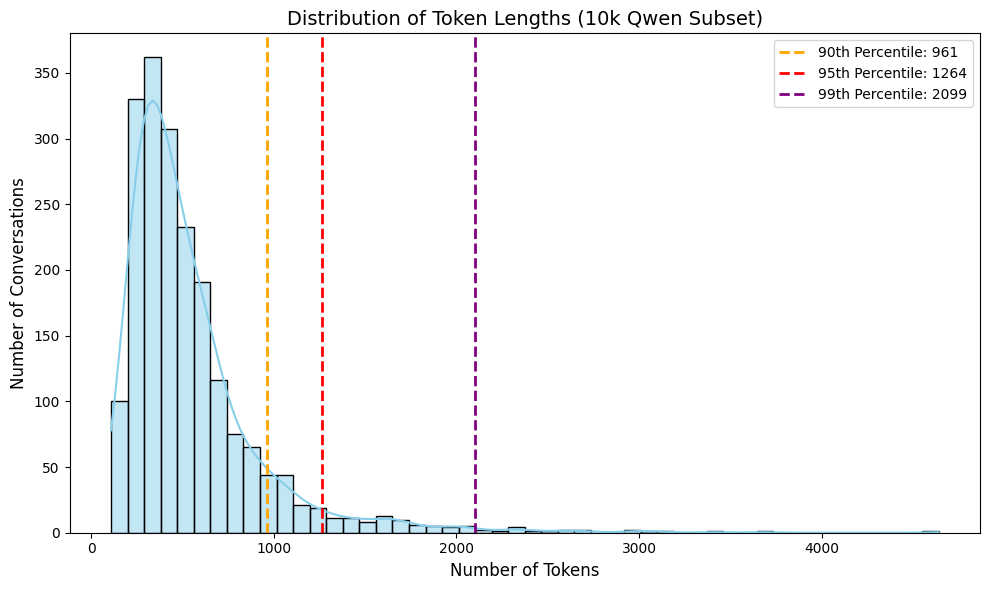

In [14]:
# 4. Plot the Distribution
plt.figure(figsize=(10, 6))
sns.histplot(token_counts, bins=50, color='skyblue', kde=True)

# Draw lines for our percentiles
plt.axvline(percentiles['90%'], color='orange', linestyle='dashed', linewidth=2, label=f"90th Percentile: {int(percentiles['90%'])}")
plt.axvline(percentiles['95%'], color='red', linestyle='dashed', linewidth=2, label=f"95th Percentile: {int(percentiles['95%'])}")
plt.axvline(percentiles['99%'], color='purple', linestyle='dashed', linewidth=2, label=f"99th Percentile: {int(percentiles['99%'])}")

plt.title('Distribution of Token Lengths (10k Qwen Subset)', fontsize=14)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Number of Conversations', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
training_args = SFTConfig(
    output_dir="./llama-3.2-3B-instruct-lora",

    # --- MEMORY MANAGEMENT ---
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=4,

    # --- LEARNING DYNAMICS ---
    learning_rate=2e-4,
    warmup_steps=20,
    num_train_epochs=3,

    # --- LOGGING & SAVING ---
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,

    # --- PRECISION & OPTIMIZER  ---
    fp16=False,
    bf16=False,
    optim="paged_adamw_8bit",

    # --- DATA FORMATTING ---
    dataset_text_field="text",
    max_length=1024,
    report_to="wandb"
)

In [16]:
# Initialize Trainer & Run
trainer = SFTTrainer(
    model=peft_model,
    train_dataset=final_dataset["train"],
    eval_dataset=final_dataset["validation"],
    args=training_args,
    processing_class=tokenizer
)

Converting train dataset to ChatML:   0%|          | 0/1800 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1800 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

In [17]:
print("Starting the fine-tuning process (Forced FP16)...")
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


Starting the fine-tuning process (Forced FP16)...


Step,Training Loss,Validation Loss
50,1.060955,1.065439
100,1.029539,1.033111


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69cd5f54-2ba03c450ea4fa6518f74b4e;86bfb226-772d-4db6-ab08-501ff5dbebd9)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-3B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-3B is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-3B.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in meta-llama/Llama-3.2-3B - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69cd65cc-461a534a168e40ff7935c6d0

Step,Training Loss,Validation Loss
50,1.060955,1.065439
100,1.029539,1.033111
150,1.008460,1.020683
200,0.952815,1.005731
250,0.895231,1.000779
300,0.898170,0.995931


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69cd6c5a-07dc67074a13b41e45db11c7;860f5456-91f5-4f3c-8806-dc12cc9e04dd)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-3B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-3B is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-3B.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in meta-llama/Llama-3.2-3B - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69cd72bc-2d2af22532067159715f6947

TrainOutput(global_step=339, training_loss=0.9834708225058947, metrics={'train_runtime': 11007.9912, 'train_samples_per_second': 0.491, 'train_steps_per_second': 0.031, 'total_flos': 7.082011393216512e+16, 'train_loss': 0.9834708225058947})

In [20]:
# Save the final adapter
trainer.model.save_pretrained("./final_lora_adapter")

# Testing The Model On Test Data

In [21]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from peft import PeftModel

In [ ]:
# 1. Define paths
base_model_id = "meta-llama/Llama-3.2-3B"
adapter_path = "./final_lora_adapter"

In [23]:
# 2. Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

In [24]:
# 3. Configure 4-bit Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# 4. Load Base Model and apply LoRA Adapter
print("Loading model and adapter...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()

Loading model and adapter...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 3072)
        (layers): ModuleList(
          (0-27): 28 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lor

In [28]:
print("Tokenizing test dataset...")
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=1024)


tokenized_test_dataset = final_dataset['test'].map(
    tokenize_function,
    batched=True,
    remove_columns=final_dataset['test'].column_names # Removes the raw text columns so Trainer doesn't complain
)

Tokenizing test dataset...


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [30]:
# 5. Set up the Data Collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# 6. Define Evaluation Arguments
eval_args = TrainingArguments(
    output_dir="./eval_output",
    per_device_eval_batch_size=4,
    do_train=False,
    do_eval=True,
    fp16=False,
    report_to="none"
)

In [33]:
# 7. Initialize Trainer
eval_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=tokenized_test_dataset,
    data_collator=data_collator
)

In [34]:
# 8. Run Evaluation (Inference + Loss Calculation)
print("Running evaluation on the test set...")
test_results = eval_trainer.evaluate()

Running evaluation on the test set...


In [35]:
# 9. Print the Results
print("\n--- Test Set Evaluation Results ---")
print(f"Test Loss: {test_results['eval_loss']:.4f}")

import math
try:
    perplexity = math.exp(test_results['eval_loss'])
    print(f"Test Perplexity: {perplexity:.4f}")
except OverflowError:
    print("Test Perplexity: Infinity")


--- Test Set Evaluation Results ---
Test Loss: 1.0185
Test Perplexity: 2.7689
